# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [9]:
import numpy as np
import seaborn as sns
import pandas as pd


Answer: In the area plot, you can see both of the line graphs at once, especailly if they are different. If the line plots are similar, then they'll overlap and you won't be able to see them properly. Therefore, if there is a stark difference between the two line graphs then go with the area plot so you can viuslize the difference side-by-side. For nitrate vs phosphate case specifically, two lines on the same axes is better since the trends are directly comparable, neither series is hidden, and a viewer can immediately see whether they rise and fall together (co-occurrence) or independently.

To improve the area graph, you can specify which of the colors (blue or orange) represents phosphate and which on is for nitrate levels. You can also make increase the line weight so the trend is more apparent. 

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

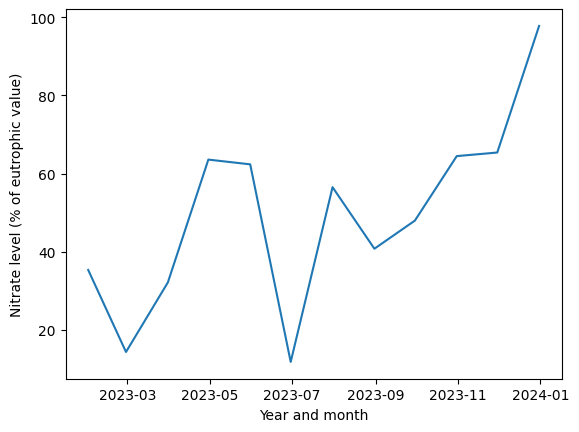

In [10]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

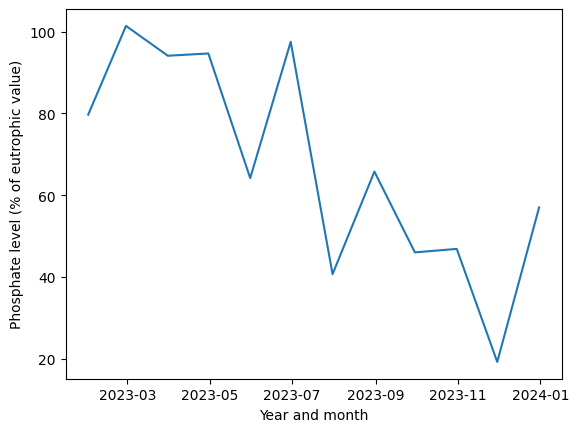

In [11]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

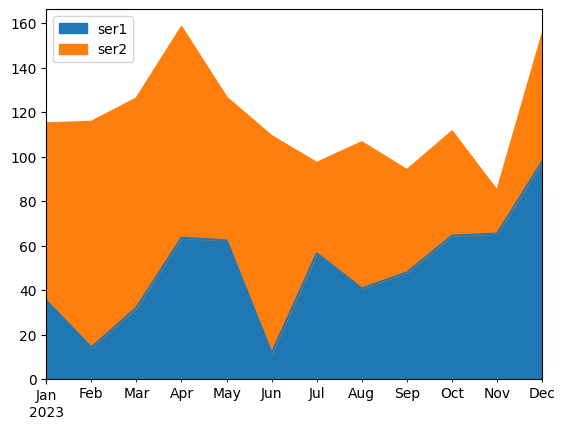

In [12]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [16]:
df = pd.read_csv('US Commerce')

In [17]:
df.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%y')


In [21]:
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
numerical_df = df[numerical_cols]

In [22]:
correlation_matrix = numerical_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
             Sales  Quantity  Discount    Profit
Sales     1.000000  0.191127 -0.033516  0.532312
Quantity  0.191127  1.000000  0.019184  0.053766
Discount -0.033516  0.019184  1.000000 -0.218343
Profit    0.532312  0.053766 -0.218343  1.000000


Sales vs Profit is the only meaningfully strong correlation which means that higher-value orders tend to generate more profit, which is expected. Since we have the disocunts aspect we can't hope for a strong correlation.

The strongest correlation in the entire dataset is 0.53 (between Sales and Profit). For two variables to be considered statistically redundant, their correlation should typically exceed 0.85 or 0.90. Because Profit relies on hidden costs (like item wholesale price) and dynamic variables (like Discount), Sales alone does not reliably predict Profit. No columns need to be dropped for redundancy.

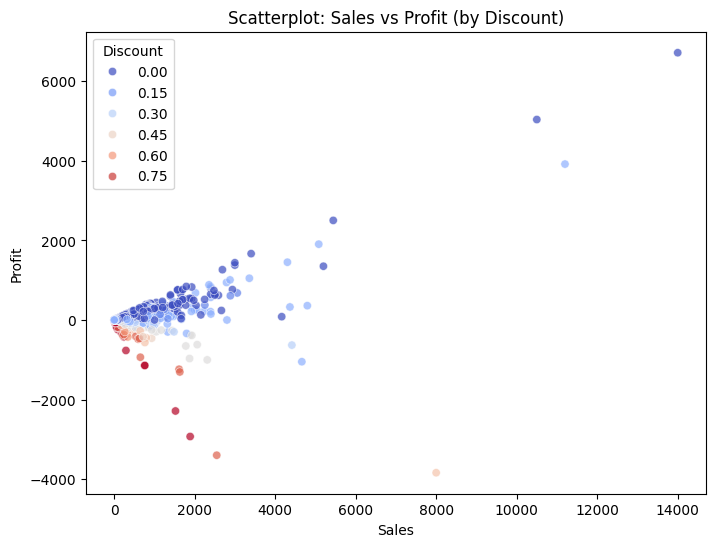

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Discount', palette='coolwarm', alpha=0.7)
plt.title('Scatterplot: Sales vs Profit (by Discount)')
plt.show()

The scatterplot maps Sales against Profit, colored by the Discount rate. It distinctly shows a "fan" shape since low-discount items trail upward (higher sales = higher profit), but high-discount items (red dots) trail downward into the negatives, revealing that massive sales volumes actually result in massive financial losses if the discount is too high.

There are obvious outliers but these are necessary for analysis. 

Text(0.5, 1.02, 'Pairplot of Numerical Variables')

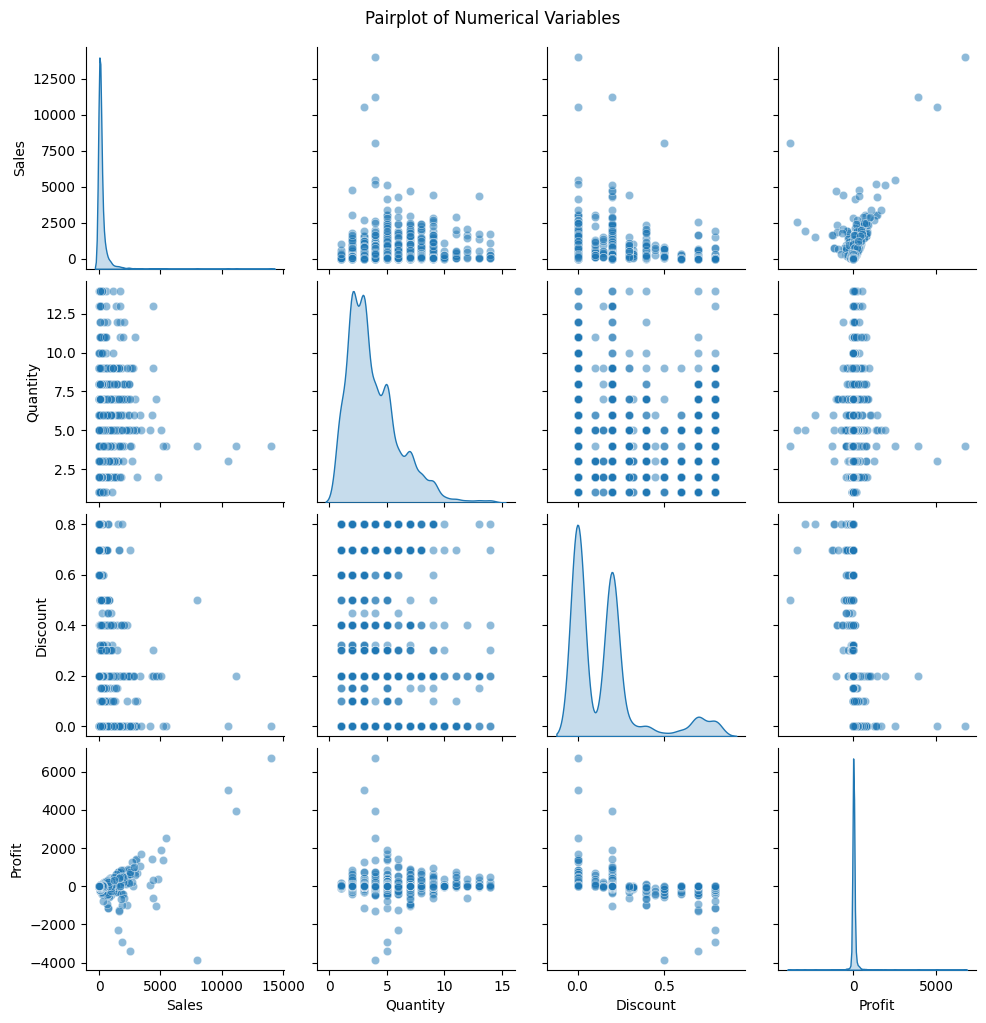

In [28]:
sns.pairplot(numerical_df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Numerical Variables', y=1.02)

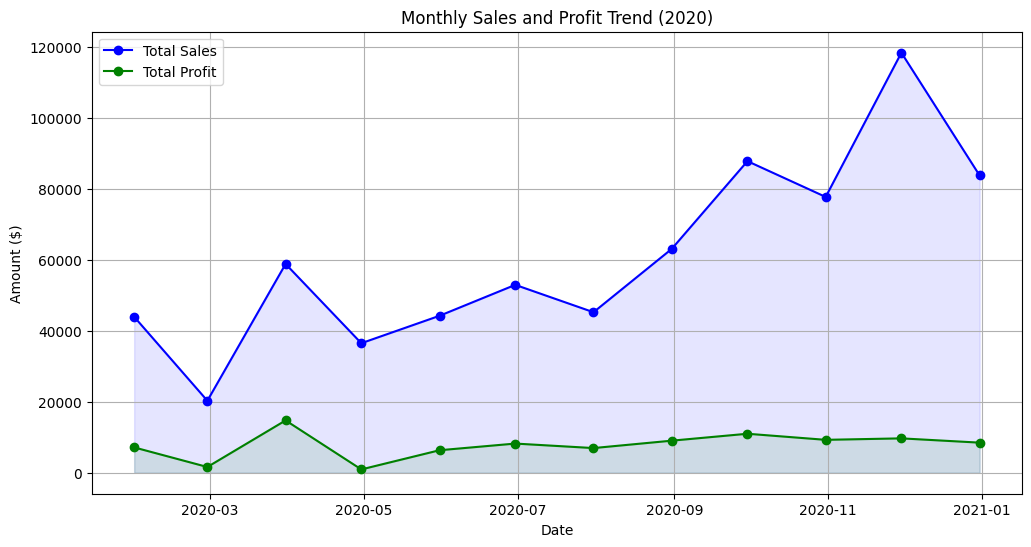

In [ ]:
df_monthly = df.set_index('Order Date').resample('ME')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Order Date'], df_monthly['Sales'], marker='o', label='Total Sales', color='blue')
plt.plot(df_monthly['Order Date'], df_monthly['Profit'], marker='o', label='Total Profit', color='green')
plt.fill_between(df_monthly['Order Date'], df_monthly['Sales'], color='blue', alpha=0.1)
plt.fill_between(df_monthly['Order Date'], df_monthly['Profit'], color='green', alpha=0.1)
plt.title('US Commerce Monthly Sales and Profit Trend (2020)')
plt.xlabel('Date')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True)

Sales and orders rise through mid-year, dip in summer, then spike sharply in November–December which is a classic holiday effect. This is entirely expected for US e-commerce.

As for confounding variables, 

Shipping Weight/Distance (Logistics Costs): The dataset shows Ship Mode and Region, but not actual package weight or exact transit distance. The massive losses seen in the "Furniture" category are highly likely confounded by extreme freight shipping costs that aren't broken out in the data.

Wholesale Price: We know the final Sales and the final Profit, but we don't know the baseline cost of the item. An item with a massive baseline markup will react differently to a 20% discount than an item with a razor-thin markup.


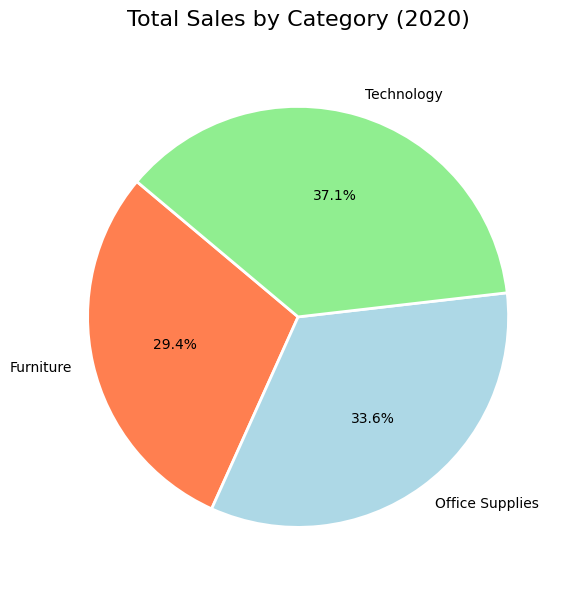

In [ ]:

category_sales = df.groupby('Category')['Sales'].sum()

plt.style.use('default')
plt.figure(figsize=(6, 6))
plt.gca().set_facecolor('white')

colors = ['coral', 'lightblue', 'lightgreen']

plt.pie(
    category_sales, 
    labels=category_sales.index, 
    autopct='%1.1f%%',          # Format percentages to 1 decimal place
    startangle=140,             # Rotate the start of the pie for better aesthetics
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Add white borders between slices
)

plt.title('Total Sales by Category (2020)', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4314/1199792541.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


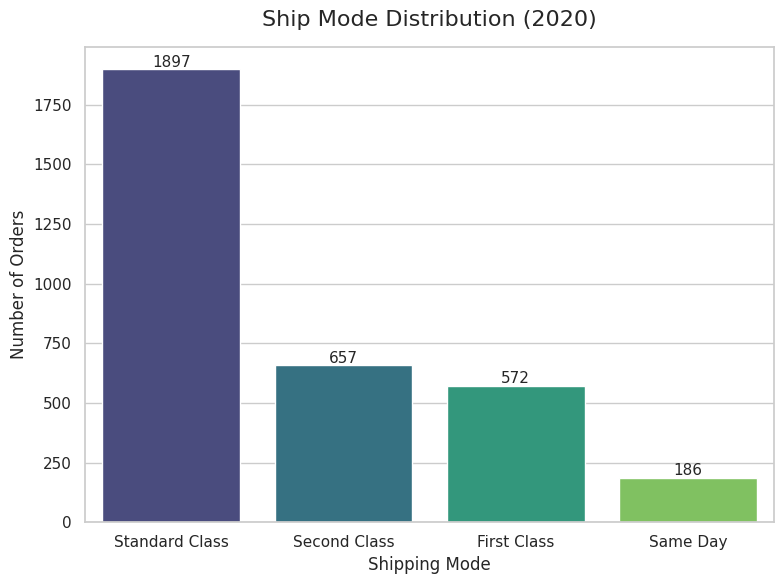

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df, 
    x='Ship Mode', 
    order=df['Ship Mode'].value_counts().index, 
    palette='viridis'  # A clean, professional color palette
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5),          # Distance from the top of the bar
                textcoords='offset points',
                fontsize=11)

plt.title('US Commerce Ship Mode Distribution (2020)', fontsize=16, pad=15)
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4314/3774970440.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


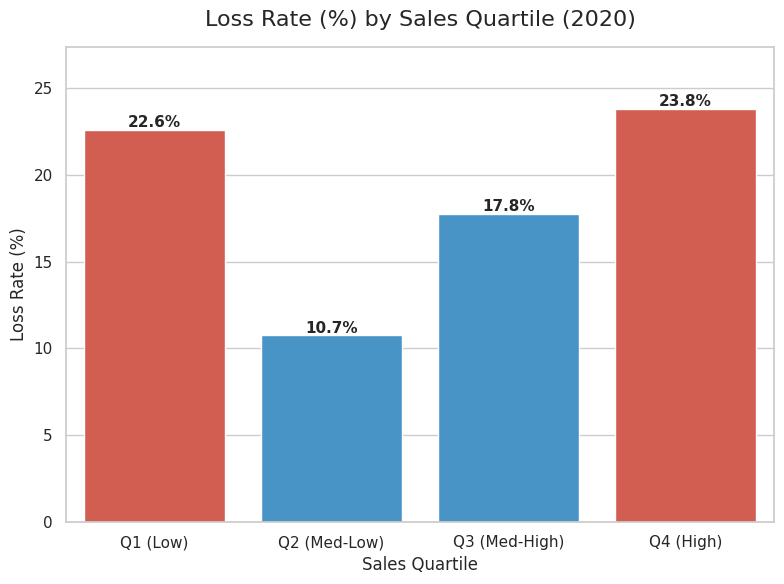

In [ ]:


df['Sales Quartile'] = pd.qcut(
    df['Sales'], 
    q=4, 
    labels=['Q1 (Low)', 'Q2 (Med-Low)', 'Q3 (Med-High)', 'Q4 (High)']
)

df['Is Loss'] = df['Profit'] < 0

loss_rate = df.groupby('Sales Quartile', observed=False)['Is Loss'].mean() * 100
loss_rate = loss_rate.reset_index()
loss_rate.rename(columns={'Is Loss': 'Loss Rate (%)'}, inplace=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

custom_colors = ['#e74c3c', '#3498db', '#3498db', '#e74c3c'] 

ax = sns.barplot(
    data=loss_rate, 
    x='Sales Quartile', 
    y='Loss Rate (%)', 
    palette=custom_colors  
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11, 
                fontweight='bold')

plt.title('Loss Rate (%) by Sales Quartile (2020)', fontsize=16, pad=15)
plt.xlabel('Sales Quartile', fontsize=12)
plt.ylabel('Loss Rate (%)', fontsize=12)

plt.ylim(0, max(loss_rate['Loss Rate (%)']) * 1.15) 

plt.tight_layout()
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

Here I have reproduced the Tcketing recieved vs processed graph

In [14]:
import matplotlib.pyplot as plt

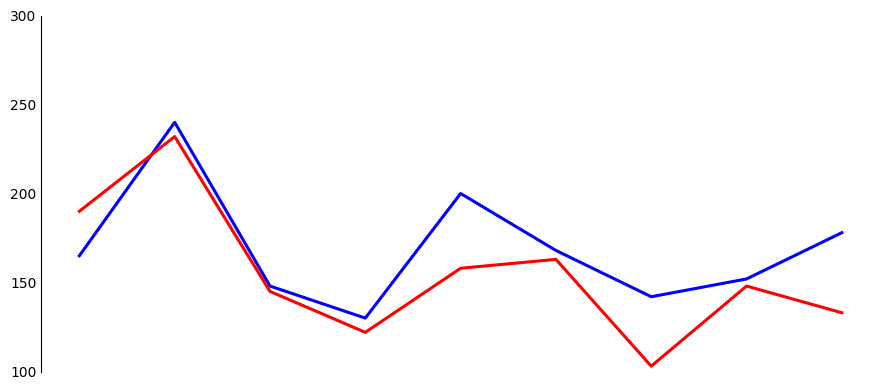

In [15]:
# Values read from the chart (9 data points each)
received  = [165, 240, 148, 130, 200, 168, 142, 152, 178]
processed = [190, 232, 145, 122, 158, 163, 103, 148, 133]

x = np.arange(len(received))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, received,  color='blue', linewidth=2.2, label='Received')
ax.plot(x, processed, color='red', linewidth=2.2, label='Processed')

ax.set_ylim(100, 300)
ax.set_yticks([100, 150, 200, 250, 300])
ax.set_xticks([])                          # no x-axis labels in original

# Match the minimal spine style of the original
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=10)

plt.tight_layout()
plt.show()